# Analytic Solutions

In [ ]:
# Add parent directory to path for imports
import sys
sys.path.insert(0, '..')

In [1]:
%load_ext autoreload
%autoreload 2
from physics import soliton_library, kdv
from scattering import ScatteringData
from plot_utils import plot_field_visualization
from configuration import kdv_config
from sampling import sample_bulk, sample_slice
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")


Using mps device.


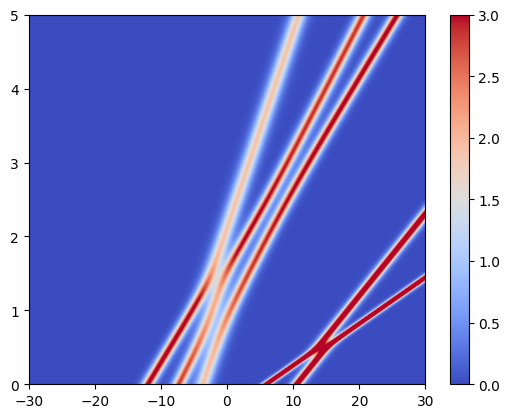

In [2]:
config = kdv_config
config.L = 30
config.T = 5
config.num_samp_eval = 512
L = config.L
T = config.T
config.kappas = [1.5, 0.97, 1.2, 1.3, 2]
config.x0s = [-5, 8, 10, 12, -4]
sd = ScatteringData(config.kappas, config.x0s, R=None, use_tau=True)


input_eval = sample_bulk(config, resample=False, num_samp=config.num_samp_eval)
input_eval.requires_grad_(True)

t = input_eval[:, 0:1]
x = input_eval[:, 1:2]
u_analytic = sd.u(x, t)
# S = soliton_library['scattering']
# u_analytic = S(input_eval, config)
# print(u_analytic)
u = u_analytic.reshape(config.num_samp_eval,config.num_samp_eval).detach().cpu().numpy()
m1 = plt.imshow(u, extent=[-L, L, 0, T],
                vmin=config.vmin, vmax=config.vmax,
                origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(m1)
results = kdv(u_analytic, input_eval)

### PDE Residuals

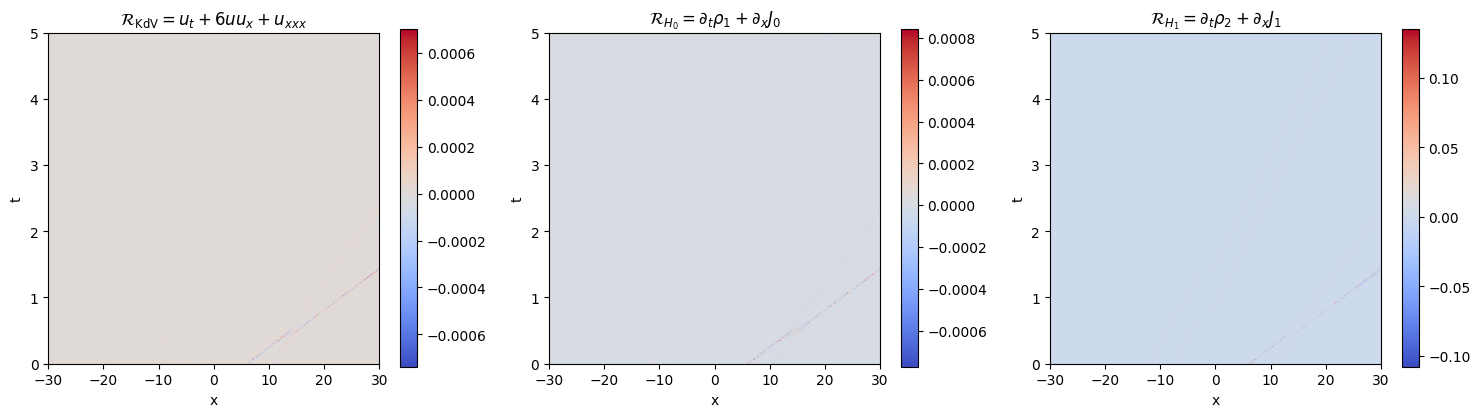

In [3]:
plot_field_visualization(results, config, 'res')

### Field Derivatives

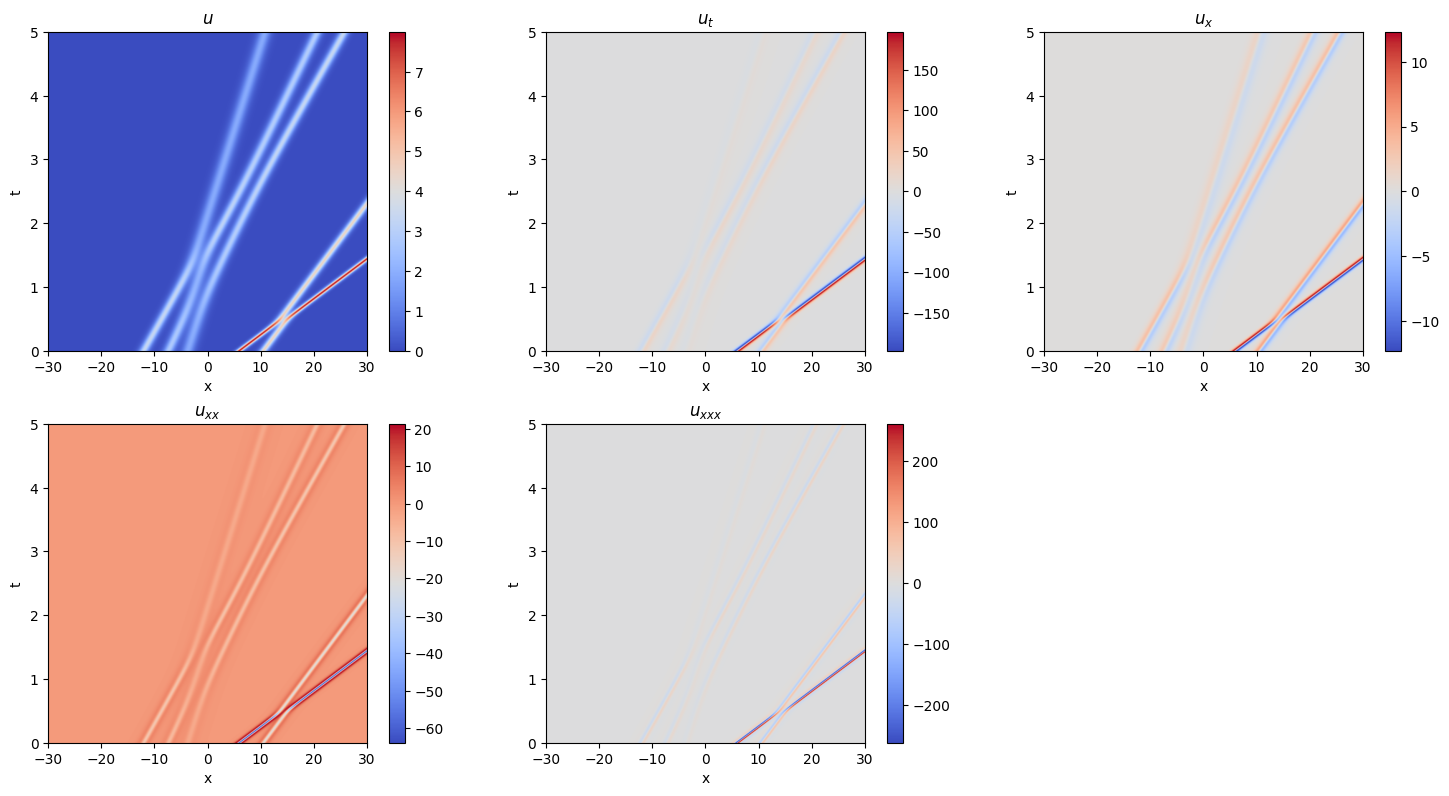

In [4]:
plot_field_visualization(results, config, 'deriv')

### Integrals of Motion

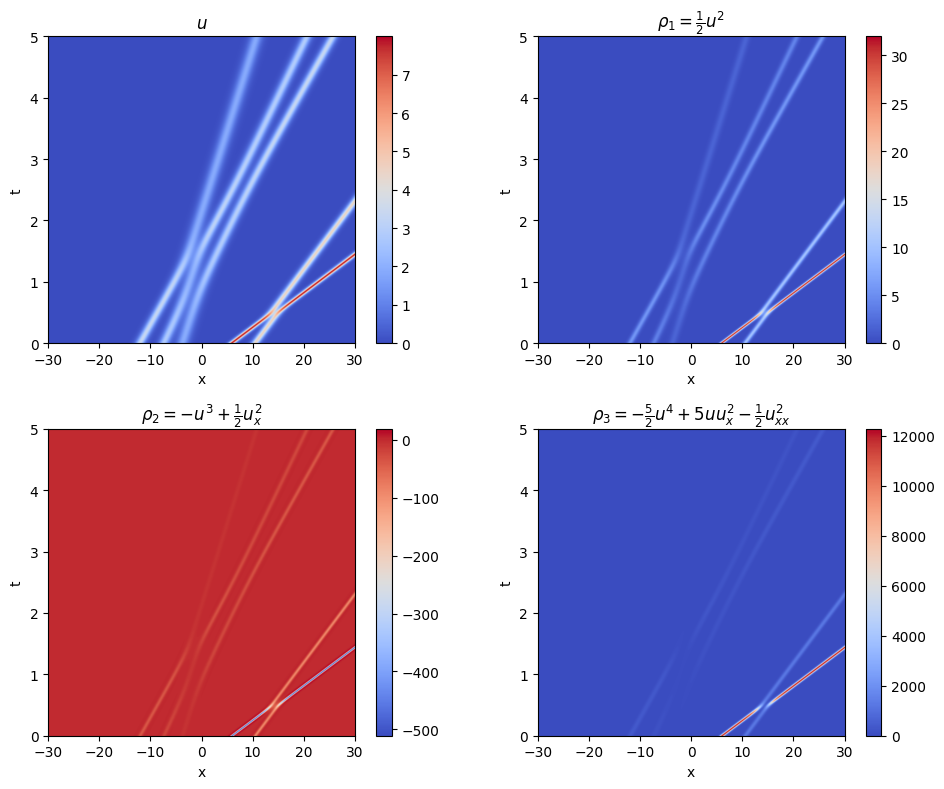

In [5]:
plot_field_visualization(results, config, 'iom')

### Conservation Currents

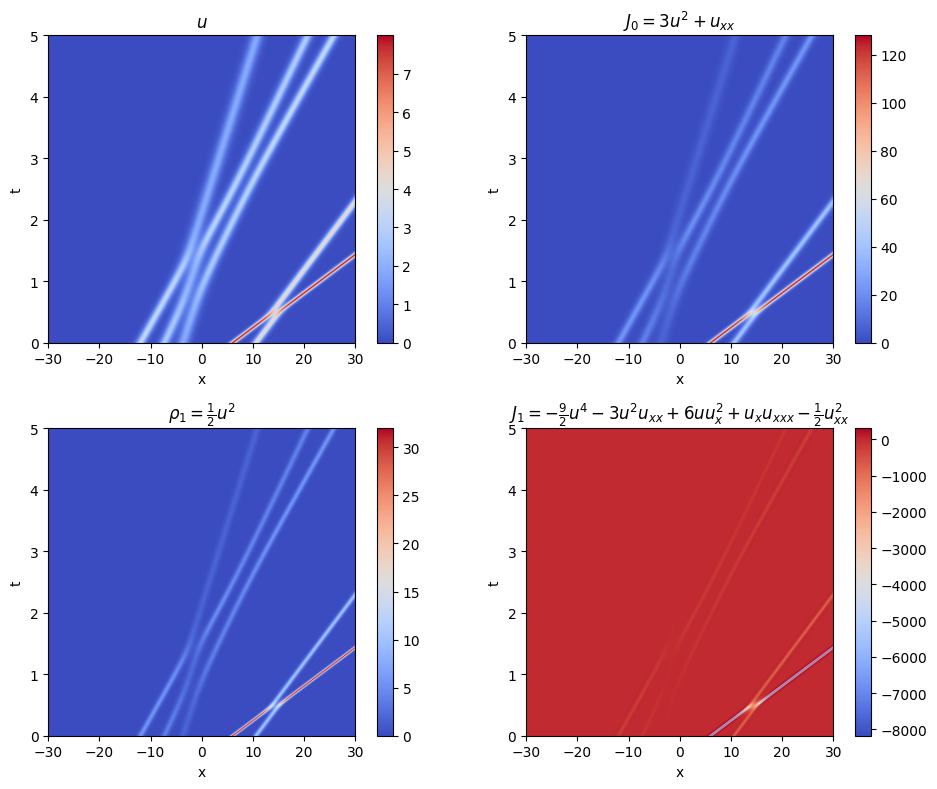

In [6]:
plot_field_visualization(results, config, 'curr')